# Import Libraries

In [39]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# Models
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import RidgeClassifier
from sklearn.linear_model import LogisticRegression

# XGBoost & LightGBM
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

import seaborn as sns
import matplotlib.pyplot as plt


# Load Dataset

In [42]:
df = pd.read_csv("/content/winequality-red.csv")

# Basic Cleaning

In [43]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


# Remove duplicate rows

In [44]:
df.drop_duplicates(inplace=True)

In [45]:
df.duplicated()

,0
0,False
1,False
2,False
3,False
5,False
...,...
1593,False
1594,False
1595,False
1597,False


In [46]:
df.duplicated().sum()

np.int64(0)

# Boxplots for Outlier Detection

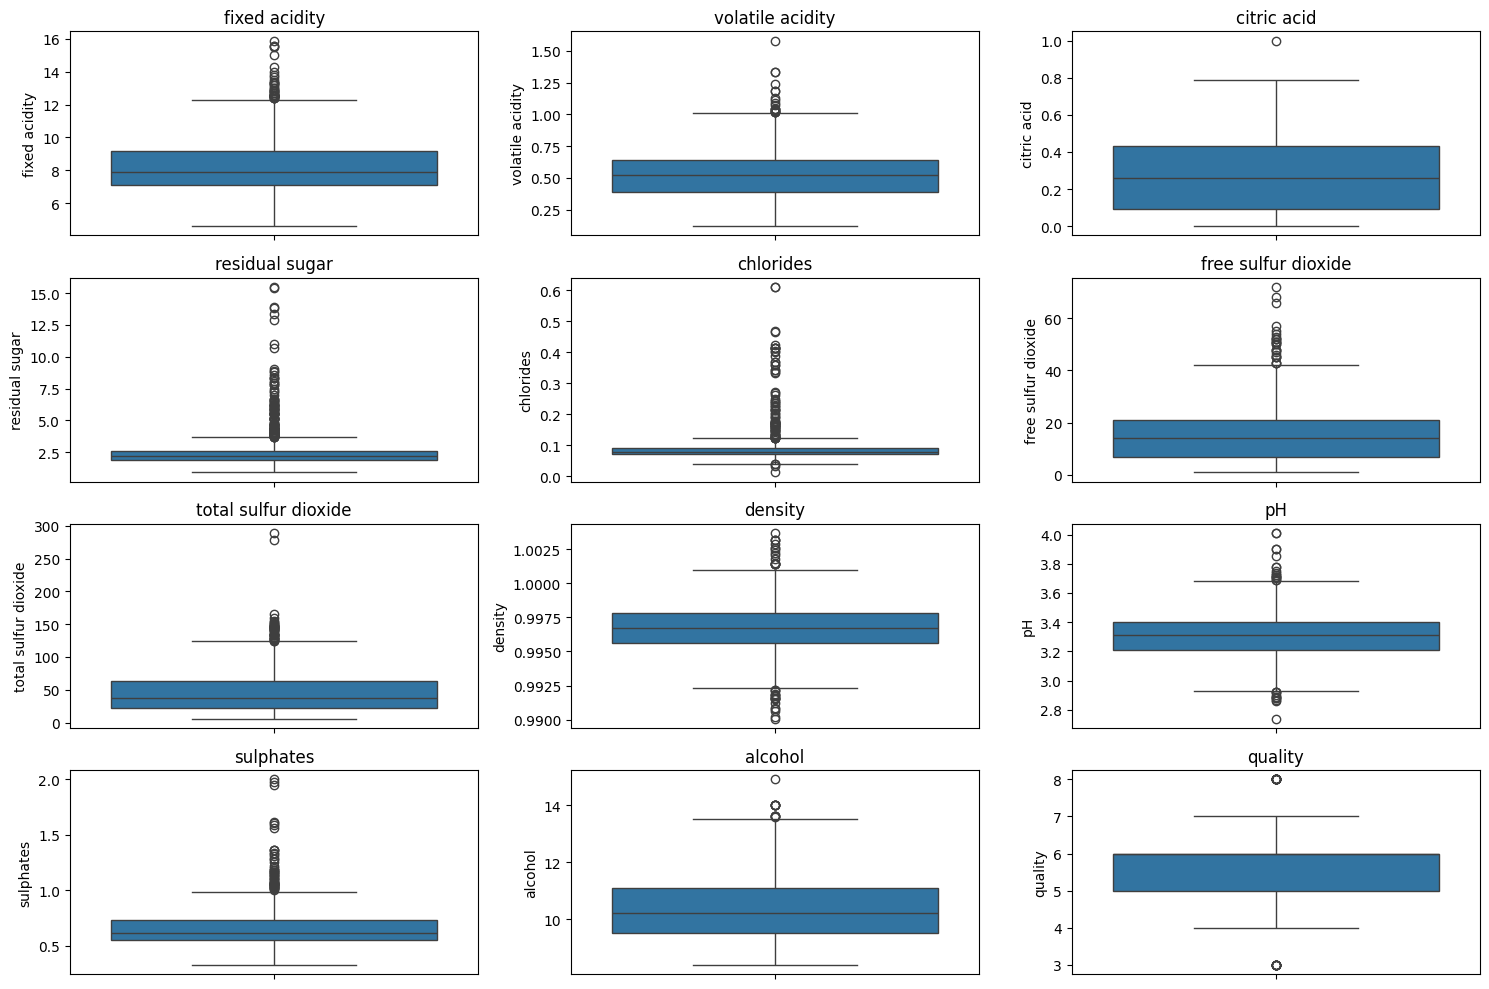

In [47]:
plt.figure(figsize=(15,10))

for i, column in enumerate(df.columns, 1):
    plt.subplot(4, 3, i)
    sns.boxplot(y=df[column])
    plt.title(column)

plt.tight_layout()
plt.show()

# Outlier Removal (Optional)

In [48]:
# Calculate Q1 and Q3
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)

# Calculate IQR
IQR = Q3 - Q1

# Remove outliers
df_no_outliers = df[
    ~((df < (Q1 - 1.5 * IQR)) |
      (df > (Q3 + 1.5 * IQR))).any(axis=1)
]

# Shape before and after
print("Original Shape:", df.shape)
print("Shape After Removing Outliers:", df_no_outliers.shape)

# Optional: Replace original dataframe
df = df_no_outliers

Original Shape: (1359, 12)
Shape After Removing Outliers: (1005, 12)


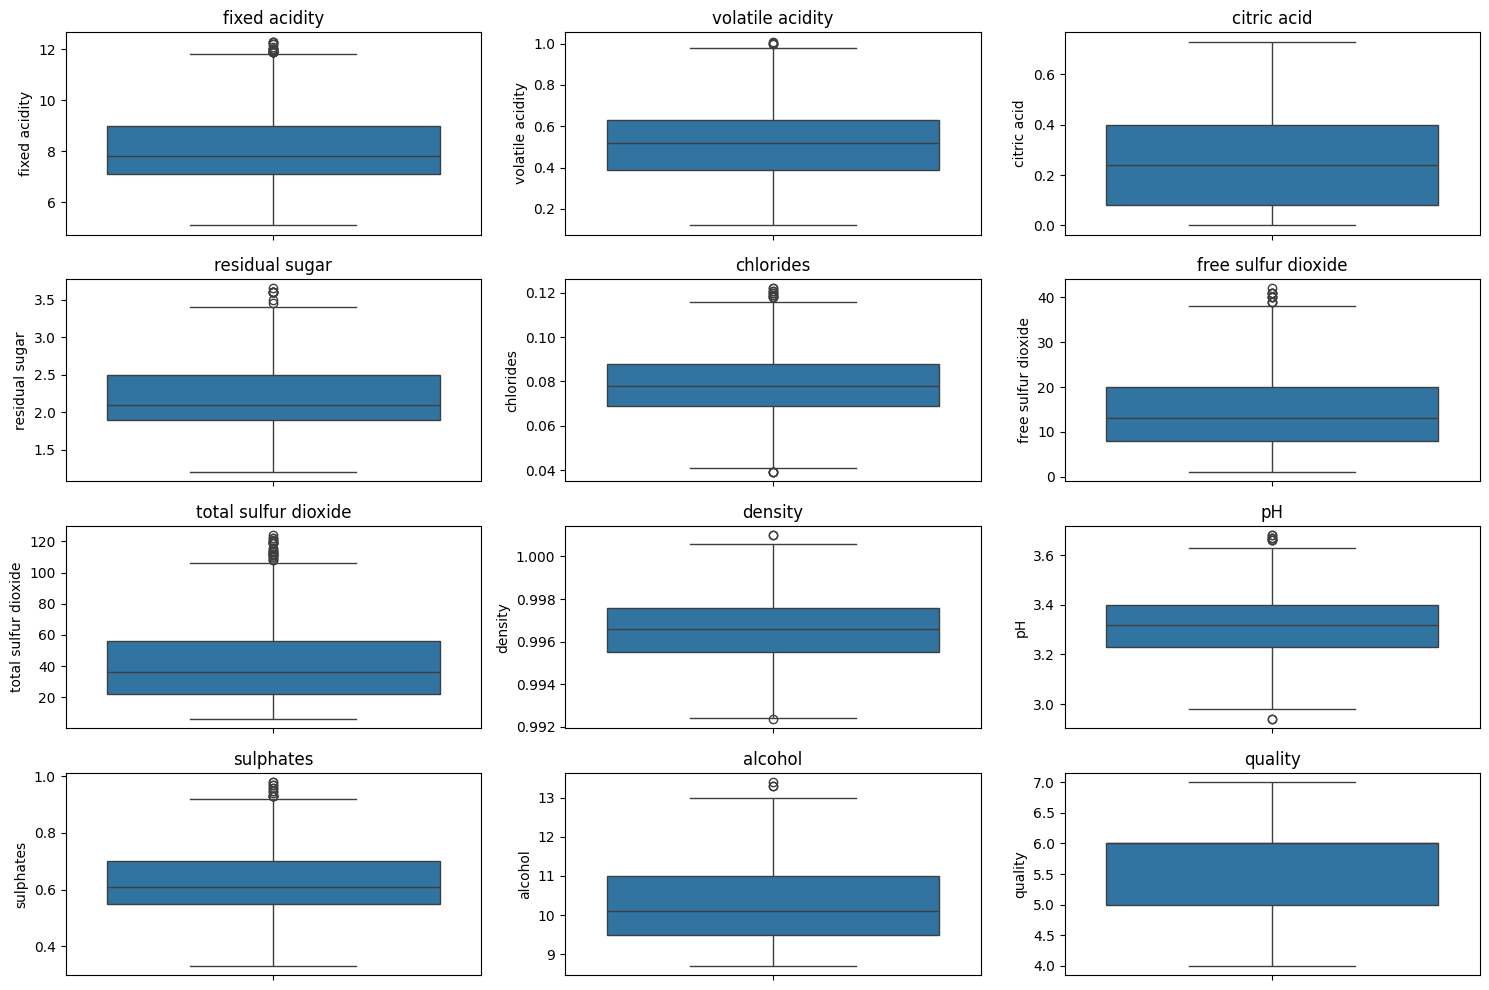

In [49]:
plt.figure(figsize=(15,10))

for i, column in enumerate(df.columns, 1):
    plt.subplot(4, 3, i)
    sns.boxplot(y=df[column])
    plt.title(column)

plt.tight_layout()
plt.show()

# Feature Engineering

# Create binary target
- Good wine = quality >= 7
- Bad wine = quality < 7

In [50]:
df['quality_label'] = df['quality'].apply(
    lambda x: 1 if x >= 7 else 0
)


# Additional engineered features

In [51]:
df['total_acidity'] = (
    df['fixed acidity'] +
    df['volatile acidity'] +
    df['citric acid']
)

df['sulfur_ratio'] = (
    df['free sulfur dioxide'] /
    (df['total sulfur dioxide'] + 1)
)

df['alcohol_acidity_ratio'] = (
    df['alcohol'] /
    (df['volatile acidity'] + 1)
)

# Feature & Target Split

In [52]:
X = df.drop(['quality', 'quality_label'], axis=1)
y = df['quality_label']


# Train-Test Split

In [53]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Feature Scaling

In [54]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Using Principal Dimensional Reduction

In [55]:
from sklearn.decomposition import PCA
pca = PCA(n_components = 4)
X_train = pca.fit_transform(X_train)
X_test = pca.transform(X_test)
explained_variance = pca.explained_variance_ratio_
print(pd.DataFrame(explained_variance))

          0
0  0.937390
1  0.054160
2  0.005668
3  0.002171


# Initialize Models

In [56]:
models = {

    "Decision Tree": DecisionTreeClassifier(
        max_depth=5,
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ),

    "Support Vector Machine": SVC(
        kernel='rbf',
        C=1,
        gamma='scale'
    ),

    "Ridge Classifier": RidgeClassifier(),

    # Lasso Regression equivalent for classification
    "Lasso Logistic Regression": LogisticRegression(
        penalty='l1',
        solver='liblinear'
    ),

    "XGBoost": XGBClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=5,
        random_state=42,
        eval_metric='logloss'
    ),

    "LightGBM": LGBMClassifier(
        n_estimators=200,
        learning_rate=0.05,
        random_state=42
    )
}

# Train & Evaluate Models

In [57]:
results = []

for name, model in models.items():

    print("\n" + "="*50)
    print(f"Model: {name}")
    print("="*50)

    # Models requiring scaled data
    if name in [
        "Support Vector Machine",
        "Ridge Classifier",
        "Lasso Logistic Regression"
    ]:
        model.fit(X_train_scaled, y_train)
        predictions = model.predict(X_test_scaled)

    else:
        model.fit(X_train, y_train)
        predictions = model.predict(X_test)

    # Accuracy
    accuracy = accuracy_score(y_test, predictions)

    print(f"\nAccuracy: {accuracy:.4f}")

    # Classification Report
    print("\nClassification Report:")
    print(classification_report(y_test, predictions))

    # Store results
    results.append({
        'Model': name,
        'Accuracy': accuracy
    })


Model: Decision Tree

Accuracy: 0.8806

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.96      0.93       178
           1       0.47      0.30      0.37        23

    accuracy                           0.88       201
   macro avg       0.69      0.63      0.65       201
weighted avg       0.86      0.88      0.87       201


Model: Random Forest

Accuracy: 0.8856

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.97      0.94       178
           1       0.50      0.26      0.34        23

    accuracy                           0.89       201
   macro avg       0.71      0.61      0.64       201
weighted avg       0.86      0.89      0.87       201


Model: Support Vector Machine

Accuracy: 0.9055

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.99      0.95       178
           1       0.75      0.26   

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


# Compare Model Performance

In [58]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by='Accuracy',
    ascending=False
)

print("\n\n===== Model Comparison =====")
print(results_df)



===== Model Comparison =====
                       Model  Accuracy
2     Support Vector Machine  0.905473
6                   LightGBM  0.895522
1              Random Forest  0.885572
4  Lasso Logistic Regression  0.885572
0              Decision Tree  0.880597
3           Ridge Classifier  0.875622
5                    XGBoost  0.875622


# Plot Accuracy Comparison

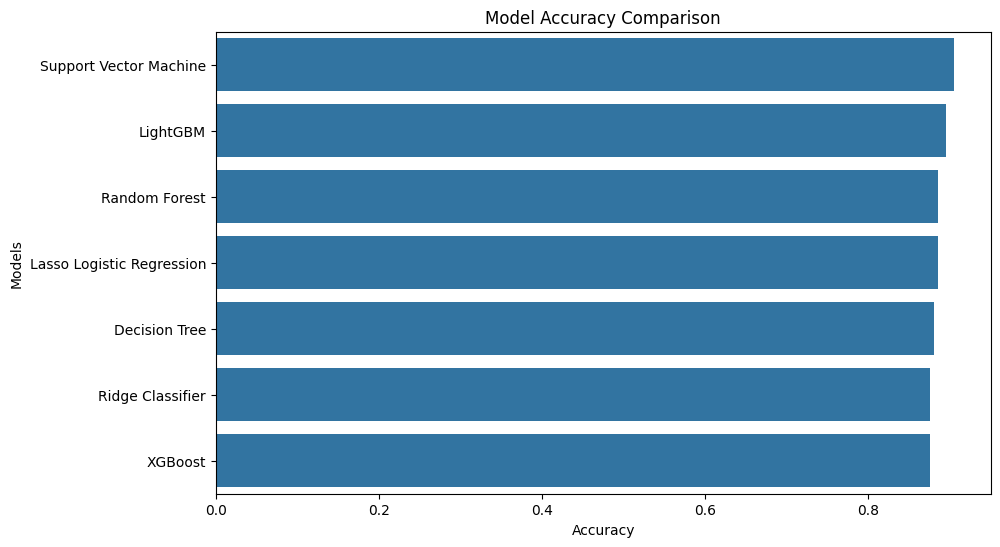

In [59]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='Accuracy',
    y='Model',
    data=results_df
)

plt.title("Model Accuracy Comparison")
plt.xlabel("Accuracy")
plt.ylabel("Models")

plt.show()

# Best Model

In [60]:
best_model_name = results_df.iloc[0]['Model']

print(f"\nBest Performing Model: {best_model_name}")


Best Performing Model: Support Vector Machine


# Save Best Model (Optional)

In [61]:
import joblib

best_model = models[best_model_name]

joblib.dump(best_model, "best_wine_quality_model.pkl")
joblib.dump(scaler, "wine_scaler.pkl")

print("\nBest model and scaler saved successfully!")


Best model and scaler saved successfully!


# Predict on New Sample

In [64]:
# Determine the appropriate input data for prediction based on how the best model was trained
if best_model_name in [
    "Support Vector Machine",
    "Ridge Classifier",
    "Lasso Logistic Regression"
]:
    # These models were trained on X_train_scaled (14 features)
    sample_input = X_test_scaled[0:1]
else:
    # These models were trained on X_train (which was overwritten by PCA output, 4 features)
    sample_input = X_test[0:1]

prediction = best_model.predict(sample_input)

print("\nSample Prediction:")

if prediction[0] == 1:
    print("Good Quality Wine")
else:
    print("Bad Quality Wine")


Sample Prediction:
Bad Quality Wine
